**CSI 4106 Introduction to Artificial Intelligence**  
*Assignment 1: Deep-Sea Mission Data Preparation*  
*Due: October 5, 2026, at 11 PM*

# Identification

Name: Cassiopeia Slavish  

Student number: 300300282

Report title: 4106-A1: Data Preparation for Model Training

# 1. Data and objective

The fictional **Abyssal Survey and Robotics Centre (ASRC)** operates
autonomous underwater vehicles for seabed mapping, environmental
monitoring, and deep-ocean surveys. Each row represents one mission. The
predictors are available before the main survey begins. The response,
`mission_interrupted`, is `1` when the vehicle returned before
completing its planned survey and `0` otherwise.

The data are fully synthetic and were created for teaching.

- [Assignment 1 data
  directory](https://github.com/turcotte/csi4106-f26/tree/main/assignments-data/a1)
- [asrc_missions_raw.csv](https://raw.githubusercontent.com/turcotte/csi4106-f26/main/assignments-data/a1/asrc_missions_raw.csv)

Consult the assignment handout for the variable descriptions and ASRC
operating context.

# 2. Data preparation and exploratory analysis

## 2.1 Load and audit the dataset

Load the supplied CSV data. The notebook must remain able to obtain the
source file from the supplied GitHub URL without a manual upload. Report
its shape, first five rows, initial data types, and number of distinct
values per column.

In [167]:
import pandas as pd

# URL upload handling
url = "https://raw.githubusercontent.com/turcotte/csi4106-f26/main/assignments-data/a1/asrc_missions_raw.csv"
dirty_data = pd.read_csv(url)

# Shape
print("Shape of the dataset:")
print(dirty_data.shape)

# First five rows
print("First five rows of the dataset:")
print(dirty_data.loc[0:4])

# Initial data types & distinct values
print("Initial data type and number of distinct values for every column:")
for col in dirty_data.columns:
  # Get data type of first value of each column; manual analysis confirms these are correctly populated values
  dataType = type(dirty_data.at[0, col])
  # Get number of distinct values in each column
  set_of_uniques = set(dirty_data[col].to_numpy())
  num = len(set_of_uniques)
  print(f"Column: {col}\n\tData type: {dataType}\n\tNum distinct values: {num}")

Shape of the dataset:
(6371, 17)
First five rows of the dataset:
     mission_id deployment_batch telemetry_protocol  planned_depth_m  \
0  ASRC-M000001       ASRC-B0253        asrc_tlm_v4           1400.0   
1  ASRC-M000002       ASRC-B0648        asrc_tlm_v4           2700.0   
2  ASRC-M000003       ASRC-B0340        asrc_tlm_v4           2870.0   
3  ASRC-M000004       ASRC-B0620        asrc_tlm_v4           2840.0   
4  ASRC-M000005       ASRC-B0332        asrc_tlm_v4           2430.0   

   planned_depth_ft  descent_current_speed_m_s water_temperature_c  \
0            4593.2                       0.55  3.3000000000000003   
1            8858.3                       0.68                 3.0   
2            9416.0                       0.15                 3.6   
3            9317.6                       0.39                 2.5   
4            7972.4                       0.34  2.8000000000000003   

      sonar_noise_db  navigation_drift_m battery_health_pct  \
0               66

**Interpretation:** see above output.

## 2.2 Handle missing values and data types

Investigate empty fields, `NA`, and `?`; convert them to `NaN`. Convert
numeric-like columns to numeric types, with parsing failures becoming
`NaN`. Report missing counts and percentages. Do not impute.

In [168]:
import math

# Copy data to new variable for handing missing vals and data types
missing_vals_data = dirty_data.copy()
# Clean " ", "NA", and "?" into NaN
toReplace_values = ["", "NA", "?"]
# Use replace() to swap out missing values [1]
for val in toReplace_values:
  missing_vals_data.replace(val, math.nan, inplace=True)

# Convert numeric-like columns to numeric types [2]
for col in missing_vals_data.select_dtypes(exclude="object"):
    missing_vals_data[col] = missing_vals_data[col].apply(pd.to_numeric, errors="coerce")

# Manually select context-specific object columns for conversion to numeric types
for col in ["water_temperature_c", "sonar_noise_db", "navigation_drift_m", "battery_health_pct", "thruster_vibration_mm_s"]:
    missing_vals_data[col] = missing_vals_data[col].apply(pd.to_numeric, errors="coerce")

# Helper function for reporting missing values
def report_missing(data, col_name):
    count = data[col_name].isna().sum()
    print(f"Column: {col_name} \n\tNum missing values: {count} of {str(len(data[col_name]))} ({100*count/len(data[col_name]):.4f}%)")

# Report on missing counts and percentages
for col in missing_vals_data.columns:
  report_missing(missing_vals_data, col)

Column: mission_id 
	Num missing values: 0 of 6371 (0.0000%)
Column: deployment_batch 
	Num missing values: 0 of 6371 (0.0000%)
Column: telemetry_protocol 
	Num missing values: 0 of 6371 (0.0000%)
Column: planned_depth_m 
	Num missing values: 0 of 6371 (0.0000%)
Column: planned_depth_ft 
	Num missing values: 0 of 6371 (0.0000%)
Column: descent_current_speed_m_s 
	Num missing values: 0 of 6371 (0.0000%)
Column: water_temperature_c 
	Num missing values: 169 of 6371 (2.6526%)
Column: sonar_noise_db 
	Num missing values: 123 of 6371 (1.9306%)
Column: navigation_drift_m 
	Num missing values: 120 of 6371 (1.8835%)
Column: battery_health_pct 
	Num missing values: 147 of 6371 (2.3073%)
Column: thruster_vibration_mm_s 
	Num missing values: 126 of 6371 (1.9777%)
Column: missions_since_service 
	Num missing values: 0 of 6371 (0.0000%)
Column: vehicle_class 
	Num missing values: 0 of 6371 (0.0000%)
Column: seabed_terrain 
	Num missing values: 0 of 6371 (0.0000%)
Column: maintenance_grade 
	Num mis

**Findings and method:** see above code and output.

## 2.3 Clean categorical attributes

Inspect every predictor represented by repeated text labels for
inconsistent category representations. Evaluate identifiers and
administrative codes in Task 2.6 rather than standardizing them merely
because they are text. Describe your investigation and cleaning method,
consolidate inconsistent labels where necessary, and show frequencies or
values before and after cleaning. Identify and state any meaningful
ordering among category levels.

In [169]:
# Copy data to new variable for handing cleaning
unclean_data = missing_vals_data.copy()

# Assessing data for cleaning...
# - vehicle_class contains 9 different string types for ultimately only 3 categories: compact, survey, and heavy
# - seabed_terrain contains 12 different string types for ultimately only 4 categories: ridge, trench, vent, and plain
# - maintenance_grade contains 14 different string types for ultimately only 4 categories: poor, good, excellent, and fair

# Cleaning data...
# Consolidate redundant string labels into their categories
vehicle_class = {"compact", "survey", "heavy"}
seabed_terrain = {"ridge", "trench", "vent", "plain"}
maintenance_grade = {"poor", "fair", "good", "excellent"}

# Function performs inplace consolidation of labels in data[col_name] to those found in set new_labels
# The elements in new_labels are substrings (case-insensitive) that consolidate all permutations of the category in the col_name to the substring version in new_labels
def consolidateLabels(data, col_name, new_labels):

  for l in new_labels:
    for i in range(len(data[col_name])):
      if (data.at[i, col_name] == data.at[i, col_name]):
        if (l in data.at[i, col_name].lower()):
          data.at[i, col_name] = l

  return

# Helper function to count quantities of each value of an attribute in the dataset
def count_attr(column):
  dictionary = {}

  for e in column:
      if e in dictionary:
        dictionary[e] = dictionary[e] + 1
      else:
        dictionary[e] = 1

  return dictionary

# Consolidate labels to consistent strings
print(f"vehicle_class pre-clean: {count_attr(unclean_data["vehicle_class"])}")
consolidateLabels(unclean_data, "vehicle_class", vehicle_class)
print(f"vehicle_class post-clean: {count_attr(unclean_data["vehicle_class"])}")

print(f"seabed_terrain pre-clean: {count_attr(unclean_data["seabed_terrain"])}")
consolidateLabels(unclean_data, "seabed_terrain", seabed_terrain)
print(f"seabed_terrain post-clean: {count_attr(unclean_data["seabed_terrain"])}")

print(f"maintenance_grade pre-clean: {count_attr(unclean_data["maintenance_grade"])}")
consolidateLabels(unclean_data, "maintenance_grade", maintenance_grade)
print(f"maintenance_grade post-clean: {count_attr(unclean_data["maintenance_grade"])}")

vehicle_class pre-clean: {'compact': 1843, 'heavy_duty': 1292, 'survey': 3140, 'Compact': 13, 'Survey': 18, 'SURVEY': 31, ' compact ': 15, 'heavy-duty': 8, 'Heavy Duty': 11}
vehicle_class post-clean: {'compact': 1871, 'heavy': 1311, 'survey': 3189}
seabed_terrain pre-clean: {'ridge': 1770, 'vent_field': 972, 'trench': 1223, 'plain': 2310, ' trench ': 13, ' plain ': 20, 'Plain': 17, 'vent-field': 5, 'Vent Field': 8, 'Trench': 9, 'Ridge': 14, 'RIDGE': 10}
seabed_terrain post-clean: {'ridge': 1794, 'vent': 985, 'trench': 1245, 'plain': 2347}
maintenance_grade pre-clean: {'good': 2481, 'fair': 1159, 'excellent': 2090, 'poor': 416, ' good ': 17, 'EXCELLENT': 23, nan: 94, 'Good': 24, nan: 35, 'FAIR': 5, 'Excellent': 18, 'Poor': 6, 'Fair': 2, ' poor ': 1}
maintenance_grade post-clean: {'good': 2522, 'fair': 1166, 'excellent': 2131, 'poor': 423, nan: 94, nan: 35}


**Findings and method:**
- vehicle_class contains 9 different string types for ultimately only 3 categories: compact, survey, and heavy
- seabed_terrain contains 12 different string types for ultimately only 4 categories: ridge, trench, vent, and plain
- maintenance_grade contains 14 different string types for ultimately only 4 categories: poor, good, excellent, and fair

The elements in new_labels are substrings (case-insensitive) that consolidate all permutations of the category in the col_name to the substring version in new_labels.

Values pre- and post-clean: see above output.

## 2.4 Apply validity rules

Use the variable meanings, units, and ASRC operating context to define
and justify validation rules. Report the affected attributes and counts,
replace invalid measurements with `NaN`, and retain unusual but possible
observations. Do not guess corrections, reconstruct values from another
column, or remove entire missions.

In [170]:
# Copy data to new variable for handing validation
unvalidated_data = unclean_data.copy()

# Validation rules:
# 1. The fleet is only certified for 6,500 m; any planned_depth_m greater than this is invalid
for i in unvalidated_data.index:
  #print(data.at[i, "planned_depth_m"])
  if unvalidated_data.at[i, "planned_depth_m"] > 1.1 * 6500:
    unvalidated_data.at[i, "planned_depth_m"] = math.nan

# 2. Battery health percentage can only be between 0 and 100; any values outside this range are invalid
for i in unvalidated_data.index:
  if unvalidated_data.at[i, "battery_health_pct"] < 0 or unvalidated_data.at[i, 'battery_health_pct'] > 100:
    unvalidated_data.at[i, "battery_health_pct"] = math.nan

# 3. Descent current speed can only be a minimum of 0 m/s
for i in unvalidated_data.index:
  if unvalidated_data.at[i, "descent_current_speed_m_s"] < 0:
    unvalidated_data.at[i, "descent_current_speed_m_s"] = math.nan

# Report counts of affected attributes
for col in ["planned_depth_m", "descent_current_speed_m_s", "battery_health_pct"]:
  report_missing(unvalidated_data, col)

Column: planned_depth_m 
	Num missing values: 6 of 6371 (0.0942%)
Column: descent_current_speed_m_s 
	Num missing values: 6 of 6371 (0.0942%)
Column: battery_health_pct 
	Num missing values: 153 of 6371 (2.4015%)


**Findings and justification:**

Validation rules:
1. The fleet is only certified for 6,500 m; any planned_depth_m greater than this is invalid
2. Battery health percentage can only be between 0 and 100; any values outside this range are invalid
3. Descent current speed can only be a minimum of 0 m/s
Affected attributes and counts: see above output.

## 2.5 Explore distributions and relationships

Before removing any attributes, create a compact summary table and
labelled histogram grid for the quantitative measurement and count
attributes. Exclude identifiers, administrative codes, categorical
labels, binary indicators, and the response, even if they are stored
numerically. At minimum, report the non-missing count, mean, standard
deviation, quartiles, minimum, maximum, and skewness.

,Attribute,Non-missing count,Mean,Standard deviation,Quartile 1,Quartile 2,Quartile 3,Minimum,Maximum,Skewness
0,planned_depth_m,6365,1999.929,1402.265,770.000,1640.000,2870.000,280.000,6290.000,0.925
1,missions_since_service,6371,12.606,7.865,7.000,11.000,17.000,0.000,55.000,1.108
2,descent_current_speed_m_s,6365,0.423,0.287,0.210,0.360,0.560,0.020,2.060,1.251
3,water_temperature_c,6202,4.060,2.268,2.400,3.600,5.700,-1.500,13.300,0.535
4,sonar_noise_db,6248,72.019,6.821,66.700,72.200,77.100,54.600,95.000,0.049
5,navigation_drift_m,6251,21.753,15.810,9.800,18.000,29.300,0.800,132.200,1.483
6,battery_health_pct,6218,87.952,4.271,85.000,88.000,91.000,67.000,99.000,-0.239
7,thruster_vibration_mm_s,6245,4.651,3.139,2.500,3.900,6.000,0.200,45.000,2.187


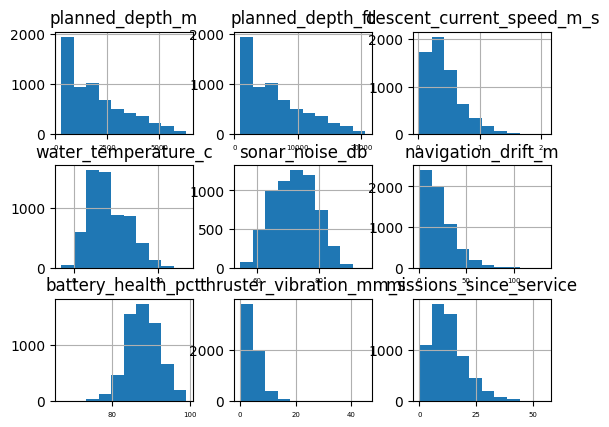

In [197]:
# Copy data to new variable for handing exploration of distributions and relationships
data = unvalidated_data.copy()

# Columns for table...
# - Non-missing count
# - Mean
# - Standard deviation
# - Quartile 1
# - Quartile 2
# - Quartile 3
# - Minimum
# - Maximum
# - Skewness

# column is a column of data in dataset
def populate_row(data, col_name):
  # array of data to perform operations upon
  arr = data[col_name]
  # calculate quartiles using numpy
  q1, q2, q3 = arr.quantile([.25, .5, .75])
  result = [
      col_name,
      arr.notna().sum(),
      arr.mean(),
      arr.std(),
      q1,
      q2,
      q3,
      arr.min(),
      arr.max(),
      data[col_name].skew()
  ]

  return result

# Compile list of applicable columns: quantitative measurements and count attributes
applicable_columns = ["planned_depth_m", "missions_since_service", "descent_current_speed_m_s", "water_temperature_c", "sonar_noise_db", "navigation_drift_m", "battery_health_pct", "thruster_vibration_mm_s"]

# Compile table data with applicable columns
table_rows = [
    populate_row(data, col_name) for col_name in applicable_columns
]

# Create table dataFrame
table = pd.DataFrame(table_rows, columns= ['Attribute', 'Non-missing count', 'Mean', 'Standard deviation', 'Quartile 1', 'Quartile 2', 'Quartile 3', 'Minimum', 'Maximum', 'Skewness'])

# Display histogram grid and table [3], [4]
data_for_exploration = data.drop(['mission_interrupted', 'firmware_current'], axis=1)
data_for_exploration.hist(xlabelsize=5)
table.style.format(precision=3)

Choose three attributes with different shapes. Discuss centre, spread,
symmetry or skewness, modality, and valid extreme observations.

**Detailed distribution analysis:**

Create a Pearson correlation heat map for the quantitative attributes.
Do not add identifiers, administrative codes, categorical encodings,
binary indicators, or the response unless specifically justified.
Discuss the strongest duplicate and non-duplicate relationships and
whether they are plausible. Add one joint plot involving at least two
attributes, and explain what it reveals beyond the univariate
histograms.

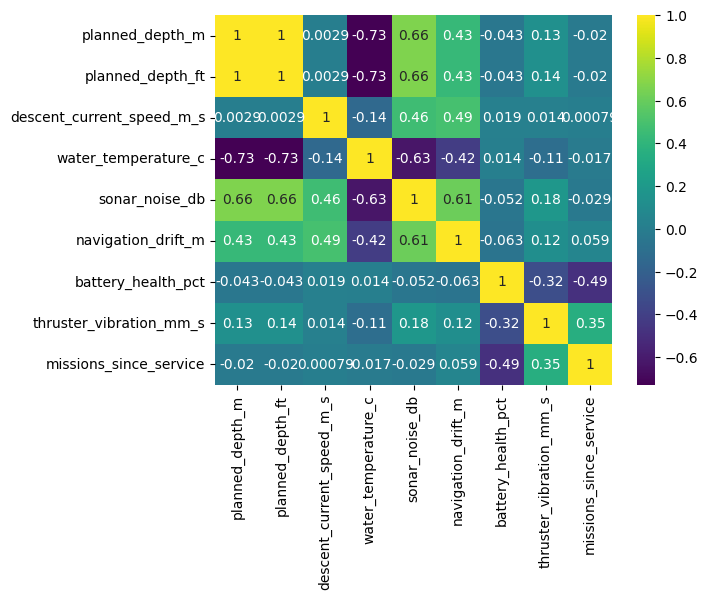

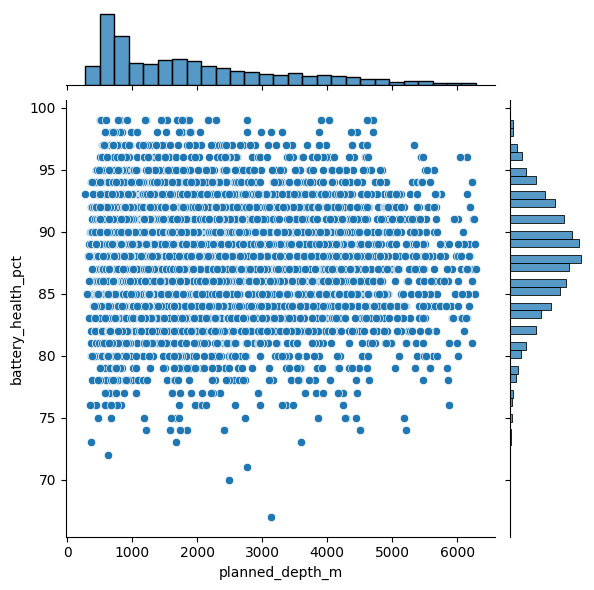

In [206]:
# 1. sonar_noise_db has an average spread, with a neutral skew and great symmetry. This makes sence, since the pre-survey sound levels would average to a middling decibel level.
# 2. battery_health_pct has a tight spread, good symmetry, and small extremes. Battery life is something that can be controlled for, and should be as high as possible.
#   The high positive skew indicates that, of the range of possible values, the batteries are maintained above 50% most of the time.
# 3. missions_since_service has a tight spread, with a negative skew. This makes sense, since most vehicles should be serviced frequently.
#   The forward-facing tail demonstrates how some vehicles rarely manage to slip by without service for long periods of time.

# Creating new copy of data with pearson correlation for only numerics
import seaborn as sns
# Create correlated matrix excluding firmware_current and mission_interrupted columns
correlated_matrix = data.drop(['firmware_current','mission_interrupted'], axis=1).corr(method="pearson", numeric_only=True)

# Create heatmap using seaborn
sns.heatmap(correlated_matrix, cmap="viridis", annot=True)

# Create joint plot using seaborn
sns.jointplot(data=data, x='planned_depth_m', y='battery_health_pct')

# The strongest duplicate relationship is planned_depth_m and planned_depth_ft, which makes sense, since we can consistently and constantly convert between the two, 1:3.28.
# The strongest non-duplicate relationship is planned_depth_m (or planned_depth_ft) and sonar_noise_db. These attributes seem to be unrelated.

# The jointplot reveals that the different planned depths of surveys did not cause the surveyors to charge the vehicle batteries different amounts beforehand. There is no correlation between these two attributes.

**Relationship analysis:**
1. sonar_noise_db has an average spread, with a neutral skew and great symmetry. This makes sence, since the pre-survey sound levels would average to a middling decibel level.
2. battery_health_pct has a tight spread, good symmetry, and small extremes. Battery life is something that can be controlled for, and should be as high as possible. The high positive skew indicates that, of the range of possible values, the batteries are maintained above 50% most of the time.
3. missions_since_service has a tight spread, with a negative skew. This makes sense, since most vehicles should be serviced frequently. The forward-facing tail demonstrates how some vehicles rarely manage to slip by without service for long periods of time.

The strongest duplicate relationship is planned_depth_m and planned_depth_ft, which makes sense, since we can consistently and constantly convert between the two, 1:3.28. The strongest non-duplicate relationship is planned_depth_m (or planned_depth_ft) and sonar_noise_db. These attributes seem to be unrelated.

The jointplot reveals that the different planned depths of surveys did not cause the surveyors to charge the vehicle batteries different amounts beforehand. There is no correlation between these two attributes.


## 2.6 Select attributes for the analysis-ready dataset

Using the preceding exploration and the meaning of each attribute,
investigate unique identifiers, high-cardinality administrative fields,
quasi-constant attributes (one value in at least 99% of observations),
and deterministic or near-deterministic duplicate measurements. List and
justify every removed attribute. Demonstrate a suspected deterministic
or alternate-unit duplicate with a direct numerical relationship, such
as a conversion error or residual; correlation alone is insufficient
evidence of duplication. Do not remove strongly correlated attributes
when they measure different concepts.

In [172]:
# mission_id, is primary key/unique identifier--since size of set == number of columns, there are no duplicates
set_of_uniques = set(data['mission_id'].to_numpy())
num = len(set_of_uniques)
print(f"Column: mission_id\tNum values: {len(data['mission_id'].to_numpy())}\tNum distinct values: {num}")

# deployment_batch is a high-cardinality administrative field with 850 values
set_of_uniques = set(data['deployment_batch'].to_numpy())
num = len(set_of_uniques)
print(f"Column: deployment_batch\tNum distinct values: {num}")

# checking for quasi-constant attributes...
for col in ['mission_interrupted', 'telemetry_protocol', 'firmware_current', 'battery_health_pct', "planned_depth_m", "missions_since_service", "descent_current_speed_m_s", "water_temperature_c", "sonar_noise_db", "navigation_drift_m"]:
  print(f"{col}: {count_attr(data[col])}")
# telemetry_protocol is a quasi-constant attribute: over 99% of the instances are "asrc_tlm_v4"

# planned_depth_ft is entirely determinable by planned_depth_m through a constant conversion ratio of 1:3.28, thus it is redundant and removable

# Thus, we will eliminate columns 'mission_id', 'deployment_batch', 'telemetry_protocol', and 'planned_depth_ft' [6]
selected_data = data.drop(['mission_id', 'deployment_batch', 'telemetry_protocol', 'planned_depth_ft'], axis=1)


Column: mission_id	Num values: 6371	Num distinct values: 6371
Column: deployment_batch	Num distinct values: 850
mission_interrupted: {0: 4295, 1: 2076}
telemetry_protocol: {'asrc_tlm_v4': 6318, 'asrc_tlm_v3': 53}
firmware_current: {1: 5157, 0: 1214}
battery_health_pct: {87.0: 516, 83.0: 268, 92.0: 389, 89.0: 607, 86.0: 488, 93.0: 302, 88.0: 620, 84.0: 359, 96.0: 100, 85.0: 438, 81.0: 141, 91.0: 470, 82.0: 228, 90.0: 544, 94.0: 228, 79.0: 65, nan: 1, 76.0: 19, 95.0: 134, 80.0: 94, 78.0: 48, nan: 1, nan: 1, nan: 1, 70.0: 1, 74.0: 7, 77.0: 25, 97.0: 59, 73.0: 3, nan: 1, nan: 1, 99.0: 24, 72.0: 1, nan: 1, nan: 1, nan: 1, nan: 1, 98.0: 26, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, 75.0: 12, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan

**Removed attributes and evidence:**

- mission_id, is primary key/unique identifier--since size of set == number of columns, there are no duplicates
- deployment_batch is a high-cardinality administrative field with 850 values
- telemetry_protocol is a quasi-constant attribute: over 99% of the instances are "asrc_tlm_v4"
- planned_depth_ft is entirely determinable by planned_depth_m through a constant conversion ratio of 1:3.28, thus it is redundant and removable
Thus, we will eliminate columns 'mission_id', 'deployment_batch', 'telemetry_protocol', and 'planned_depth_ft'.


## 2.7 Examine the response

Report counts and proportions for `mission_interrupted`, include a
labelled bar chart, and briefly characterize the class balance. Do not
train a model.

Count of each outcome: {0: 4295, 1: 2076}
Percentage of success: 67.4148%
Percentage of failure: 32.5852%


<Axes: xlabel='mission_interrupted'>

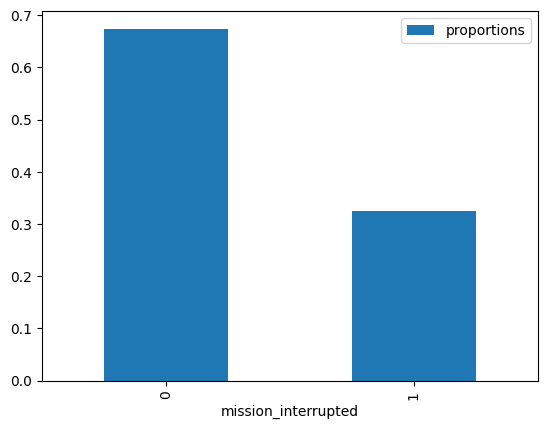

In [207]:
# Display count of each type of attribute for column
mission_interrupted_vals = count_attr(selected_data['mission_interrupted'])
print(f"Count of each outcome: {mission_interrupted_vals}")
proportions = [
    mission_interrupted_vals[0]/(mission_interrupted_vals[0] + mission_interrupted_vals[1]),
    mission_interrupted_vals[1]/(mission_interrupted_vals[0] + mission_interrupted_vals[1])
]
print(f"Percentage of success: {100*proportions[0]:.4f}%")
print(f"Percentage of failure: {100*proportions[1]:.4f}%")

pd.DataFrame({"mission_interrupted": [0, 1], "proportions": proportions}).plot.bar(x="mission_interrupted", y="proportions")

# The class balance favours missions that were successful/uninterrupted by a factor of 2:1. This is a slightly imbalanced data set.

**Interpretation:** see above output. The class balance favours missions that were successful/uninterrupted by a factor of 2:1. This is a slightly imbalanced data set.

## 2.8 Export the cleaned data

Retain the attributes you selected for the analysis-ready dataset and
`mission_interrupted`. Keep the retained predictors in their original
dataset order and place the response last. Leave unavailable or invalid
predictor measurements as `NaN`. Save the table as
`asrc_missions_cleaned.csv` without an index column. Reload the saved
CSV and verify its filename, shape, column names and order, categorical
labels, numeric measurements, missing values, row order, response, and
absence of an extra index column.

In [208]:
#Dataset columns are already in the above requested order
print(selected_data)

#Save dataset to csv
selected_data.to_csv("asrc_missions_cleaned.csv", index=False)

#Import colab library to perform file download
from google.colab import files
files.download("asrc_missions_cleaned.csv")

      planned_depth_m  descent_current_speed_m_s  water_temperature_c  \
0              1400.0                       0.55                  3.3   
1              2700.0                       0.68                  3.0   
2              2870.0                       0.15                  3.6   
3              2840.0                       0.39                  2.5   
4              2430.0                       0.34                  2.8   
...               ...                        ...                  ...   
6366            710.0                       0.35                  4.9   
6367           2120.0                       0.27                  2.6   
6368           1910.0                       0.74                  1.5   
6369           1280.0                       0.64                  4.6   
6370           5480.0                       0.29                  2.0   

      sonar_noise_db  navigation_drift_m  battery_health_pct  \
0               66.0                10.4                87.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Final validation:** see above output.

# References

List all external sources using the IEEE numbered reference style
described in the handout. Cite adapted code in a nearby comment or
Markdown cell. If you did not use external sources, state “No external
sources were used.” You remain responsible for verifying, understanding,
and explaining everything in your submission.

[1] The pandas development team, "pandas.DataFrame.replace," *pandas documentation*. Accessed: Oct 5, 2026. [Online] Available: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html

[2] The pandas development team, "pandas.DataFrame.convert_dtypes," *pandas documentation*. Accessed: Oct 5, 2026. [Online] Available: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.convert_dtypes.html#pandas.DataFrame.convert_dtypes

[3] The pandas development team, "Table Visualization," *pandas documentation*. Accessed: Oct 5, 2026. [Online] Available: https://pandas.pydata.org/docs/user_guide/style.html

[4] The pandas development team, "pandas.DataFrame.hist," *pandas documentation*. Accessed: Oct 5, 2026. [Online] Available: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html

[5] The Geeks for Geeks web team, "How to create a correlation heatmap in Python?," *Geeks for Geeks tutorial*. Accessed: Oct 5, 2026. [Online] Available: https://www.geeksforgeeks.org/python/how-to-create-a-seaborn-correlation-heatmap-in-python/

[6] The pandas development team, "pandas.DataFrame.drop," *pandas documentation*. Accessed: Oct 5, 2026. [Online] Available: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html


# AI Use Declaration

**1. Did you use a generative AI tool while completing this
assignment?** This includes assistance with code, debugging, analysis,
interpretation, writing, translation, or finding sources.

**Answer:** No

If you answered **No**, mark the confirmation below and omit questions 2
through 6 and the AI Interaction Transcript.

- [X] I confirm that I did not use generative AI in preparing this
  submission.

If you answered **Yes**, complete questions 2 through 6.

**2. Which tools and models or versions did you use?**

**Answer:**

**3. How did you use generative AI?** Select all that apply.

- [ ] Clarifying concepts or checking my understanding
- [ ] Brainstorming or planning an approach
- [ ] Writing or revising code
- [ ] Debugging code or interpreting error messages
- [ ] Interpreting data, results, tables, or plots
- [ ] Writing or revising explanations
- [ ] Translation
- [ ] Finding references or documentation
- [ ] Other:

**4. Briefly identify the sections or tasks for which AI assistance was
used and describe how it influenced your work.**

**Answer:**

**5. How did you verify the AI-generated suggestions, code, or
explanations?**

**Answer:**

**6. Confirmation**

- [ ] I confirm that this declaration is complete, that the required
  transcript is included below, and that I understand and can explain
  everything in my submission.

# AI Interaction Transcript

If you used AI assistance, identify each conversation or session in the
numbered references and include the complete transcript here. If you did
not use AI assistance, omit this section.